# Task 3 — Heterogeneous Task Mix (Ks + Kt)

## Scenario
Both task classes coexist on the same sensing nodes. Each arrival is **delay-sensitive (Ks)** with probability $\alpha$, otherwise **delay-tolerant (Kt)**. Each task is offloaded to the HAPS with probability $p$, else processed locally.

## Parameters
| Parameter | Value |
|-----------|-------|
| $M=10$, $\lambda=2$ tasks/s/node, $N=2$ HAPS servers | |
| **Ks**: $\bar{C}=5\times10^6$, $L=2$ Mbit, $D_{\max}=0.5$ s | |
| **Kt**: $\bar{C}=5\times10^7$, $L=10$ Mbit, $D_{\max}=10$ s | |
| $\alpha$ | **low** $=0.2$, **medium** $=0.5$, **high** $=0.8$ |
| $p$ | $\{0,\,0.25,\,0.5,\,0.75,\,1\}$ |
| Simulation | `SIM_TIME=50,000` s, warm-up `10,000` s |

## Task 3.a — Metrics
1. **Delay** — $E[T]_{Ks}$, $E[T]_{Kt}$
2. **QoS** — fraction meeting deadline per class
3. **System load** — local/HAPS utilisation and buffer occupancy

> One figure (all $\alpha$ levels, different colours), $p$ on the x-axis: `task3_mixed.png`

In [1]:
import random
import numpy as np
from queue import PriorityQueue

# ── Parameters (Task 2 / tips.md) ─────────────────────────────────────────────
M, LAM = 10, 2.0
F_LOC, F_HAPS = 1e8, 1e9
B_LOC, N_HAPS, B_HAPS = 20, 2, 200
R_UL, T_PROP = 10e6, 0.002
SIM_TIME, WARMUP_T, SEED = 50_000, 10_000, 42

TASKS = {
    'Ks': {'L': 2e6,  'C_mean': 5e6,  'Dmax': 0.5},
    'Kt': {'L': 10e6, 'C_mean': 5e7,  'Dmax': 10.0},
}

ALPHA_CFG = {
    'low':    0.2,   # 20 % delay-sensitive
    'medium': 0.5,   # 50 % delay-sensitive
    'high':   0.8,   # 80 % delay-sensitive
}
P_VALUES = np.array([0.0, 0.25, 0.5, 0.75, 1.0])
METRICS = ['ET_Ks', 'ET_Kt', 'QoS_Ks', 'QoS_Kt',
           'loc_util', 'hap_util', 'loc_occ', 'hap_occ']

CFG = (
    f"M={M} | lambda={LAM} tasks/s/node | N={N_HAPS} HAPS | "
    f"SIM_TIME={SIM_TIME:,}s | warm-up={WARMUP_T:,}s | "
    f"alpha={{low:0.2, med:0.5, high:0.8}} | p in {{0,0.25,0.5,0.75,1}}"
)


def sample_proc(C_mean, F, rng):
    return rng.expovariate(1.0 / C_mean) / F


def simulate_mixed(alpha, p, seed=SEED):
    rng = random.Random(seed)
    loc_q = [[] for _ in range(M)]
    loc_busy, loc_n = [False] * M, [0] * M
    hap_q, hap_busy, hap_n = [], [False] * N_HAPS, 0

    hap_busy_area = hap_busy_old_t = 0.0
    loc_busy_area = [0.0] * M
    loc_busy_old_t = [0.0] * M
    loc_occ_area = loc_occ_old_t = 0.0
    hap_occ_area = hap_occ_old_t = 0.0

    FES = PriorityQueue()
    for m in range(M):
        FES.put((rng.expovariate(LAM), 'arr', m))

    def blank():
        return dict(loc_n=0, hap_n=0, loc_d=0.0, hap_d=0.0,
                    loc_viol=0, hap_viol=0)

    stats = {tc: blank() for tc in TASKS}

    def hap_int(t):
        nonlocal hap_busy_area, hap_busy_old_t, hap_occ_area, hap_occ_old_t
        dt = t - hap_busy_old_t
        hap_busy_area += sum(hap_busy) * dt
        hap_occ_area += hap_n * dt
        hap_busy_old_t = hap_occ_old_t = t

    def loc_int(t):
        nonlocal loc_occ_area, loc_occ_old_t
        dt = t - loc_occ_old_t
        for m in range(M):
            loc_busy_area[m] += int(loc_busy[m]) * dt
        loc_occ_area += sum(loc_n) * dt
        loc_occ_old_t = t

    def record_loc(t, gen_t, tc):
        if t < WARMUP_T:
            return
        d = t - gen_t
        s = stats[tc]
        s['loc_n'] += 1
        s['loc_d'] += d
        if d > TASKS[tc]['Dmax']:
            s['loc_viol'] += 1

    def record_hap(t, gen_t, tc):
        if t < WARMUP_T:
            return
        d = t - gen_t
        s = stats[tc]
        s['hap_n'] += 1
        s['hap_d'] += d
        if d > TASKS[tc]['Dmax']:
            s['hap_viol'] += 1

    def on_arrival(t, m):
        nonlocal hap_n
        FES.put((t + rng.expovariate(LAM), 'arr', m))
        tc = 'Ks' if rng.random() < alpha else 'Kt'
        L, C_mean = TASKS[tc]['L'], TASKS[tc]['C_mean']
        t_tx = L / R_UL

        if rng.random() < p:
            hap_int(t)
            if max(0, hap_n - sum(hap_busy)) >= B_HAPS:
                return
            hap_n += 1
            srv = next((i for i, b in enumerate(hap_busy) if not b), None)
            ah = t + t_tx + T_PROP
            if srv is not None:
                hap_busy[srv] = True
                pt = sample_proc(C_mean, F_HAPS, rng)
                ps = max(t, ah)
                FES.put((ps + pt, 'hap_dep', srv, t, ah, ps, pt, tc))
            else:
                hap_q.append((ah, t, tc))
        else:
            loc_int(t)
            if loc_n[m] - int(loc_busy[m]) >= B_LOC:
                return
            loc_n[m] += 1
            loc_q[m].append((t, tc))
            if not loc_busy[m]:
                loc_busy[m] = True
                gt, tc2 = loc_q[m].pop(0)
                pt = sample_proc(TASKS[tc2]['C_mean'], F_LOC, rng)
                FES.put((t + pt, 'loc_dep', m, gt, pt, tc2))

    def on_loc_dep(t, m, gen_t, proc_t, tc):
        loc_int(t)
        loc_n[m] -= 1
        record_loc(t, gen_t, tc)
        if loc_q[m]:
            gt2, tc2 = loc_q[m].pop(0)
            pt2 = sample_proc(TASKS[tc2]['C_mean'], F_LOC, rng)
            FES.put((t + pt2, 'loc_dep', m, gt2, pt2, tc2))
        else:
            loc_busy[m] = False

    def on_hap_dep(t, srv, gen_t, ah, ps, pt, tc):
        nonlocal hap_n
        hap_int(t)
        hap_n -= 1
        record_hap(t, gen_t, tc)
        if hap_q:
            ah2, gt2, tc2 = hap_q.pop(0)
            pt2 = sample_proc(TASKS[tc2]['C_mean'], F_HAPS, rng)
            ps2 = max(t, ah2)
            hap_busy[srv] = True
            FES.put((ps2 + pt2, 'hap_dep', srv, gt2, ah2, ps2, pt2, tc2))
        else:
            hap_busy[srv] = False

    time = 0.0
    while time < SIM_TIME:
        ev = FES.get()
        time = ev[0]
        if ev[1] == 'arr':
            on_arrival(time, ev[2])
        elif ev[1] == 'loc_dep':
            on_loc_dep(time, ev[2], ev[3], ev[4], ev[5])
        elif ev[1] == 'hap_dep':
            on_hap_dep(time, ev[2], ev[3], ev[4], ev[5], ev[6], ev[7])

    hap_int(SIM_TIME)
    loc_int(SIM_TIME)
    obs_t = SIM_TIME - WARMUP_T
    sd = lambda a, b: a / b if b else float('nan')

    out = {}
    for tc in TASKS:
        s = stats[tc]
        n = s['loc_n'] + s['hap_n']
        out[f'ET_{tc}'] = sd(s['loc_d'] + s['hap_d'], n)
        out[f'QoS_{tc}'] = 1 - sd(s['loc_viol'] + s['hap_viol'], n) if n else float('nan')

    out['loc_util'] = sum(loc_busy_area) / (M * obs_t)
    out['hap_util'] = hap_busy_area / (N_HAPS * obs_t)
    out['loc_occ'] = loc_occ_area / (M * obs_t)
    out['hap_occ'] = hap_occ_area / obs_t
    return out


# ── Sweep ─────────────────────────────────────────────────────────────────────
results = {label: {k: [] for k in METRICS} for label in ALPHA_CFG}

print("Task 3.a — mixed-traffic sweep\n" + CFG + "\n")
for label, alpha in ALPHA_CFG.items():
    print(f"=== alpha = {alpha} ({label}: {100*alpha:.0f}% Ks, {100*(1-alpha):.0f}% Kt) ===")
    hdr = (f"{'p':>5} | {'E[T]_Ks':>8} | {'E[T]_Kt':>8} | {'QoS_Ks':>7} | {'QoS_Kt':>7} | "
           f"{'loc_util':>8} | {'hap_util':>8} | {'loc_occ':>7} | {'hap_occ':>7}")
    print(hdr)
    print("-" * len(hdr))
    for i, p in enumerate(P_VALUES):
        r = simulate_mixed(alpha, float(p), seed=SEED + int(alpha * 1000) + i * 17)
        for k in METRICS:
            results[label][k].append(r[k])
        print(
            f"{p:>5.2f} | {r['ET_Ks']:>8.3f} | {r['ET_Kt']:>8.3f} | "
            f"{r['QoS_Ks']:>7.3f} | {r['QoS_Kt']:>7.3f} | "
            f"{r['loc_util']:>8.3f} | {r['hap_util']:>8.3f} | "
            f"{r['loc_occ']:>7.3f} | {r['hap_occ']:>7.3f}"
        )
    print()

Task 3.a — mixed-traffic sweep
M=10 | lambda=2.0 tasks/s/node | N=2 HAPS | SIM_TIME=50,000s | warm-up=10,000s | alpha={low:0.2, med:0.5, high:0.8} | p in {0,0.25,0.5,0.75,1}

=== alpha = 0.2 (low: 20% Ks, 80% Kt) ===
    p |  E[T]_Ks |  E[T]_Kt |  QoS_Ks |  QoS_Kt | loc_util | hap_util | loc_occ | hap_occ
-----------------------------------------------------------------------------------------
 0.00 |    2.032 |    2.478 |   0.313 |   0.992 |    1.021 |    0.000 |   5.927 |   0.000
 0.25 |    0.781 |    1.231 |   0.512 |   1.000 |    0.770 |    1.202 |   2.247 |   6.024
 0.50 |    0.602 |    0.948 |   0.413 |   1.000 |    0.514 |    1.249 |   0.941 |  12.568
 0.75 |    0.716 |    0.948 |   0.232 |   1.000 |    0.257 |    1.250 |   0.335 |  19.220
 1.00 |    0.942 |    1.062 |   0.001 |   1.000 |    0.000 |    1.250 |   0.000 |  25.910

=== alpha = 0.5 (medium: 50% Ks, 50% Kt) ===
    p |  E[T]_Ks |  E[T]_Kt |  QoS_Ks |  QoS_Kt | loc_util | hap_util | loc_occ | hap_occ
-----------------

Saved and displayed task3_mixed.png


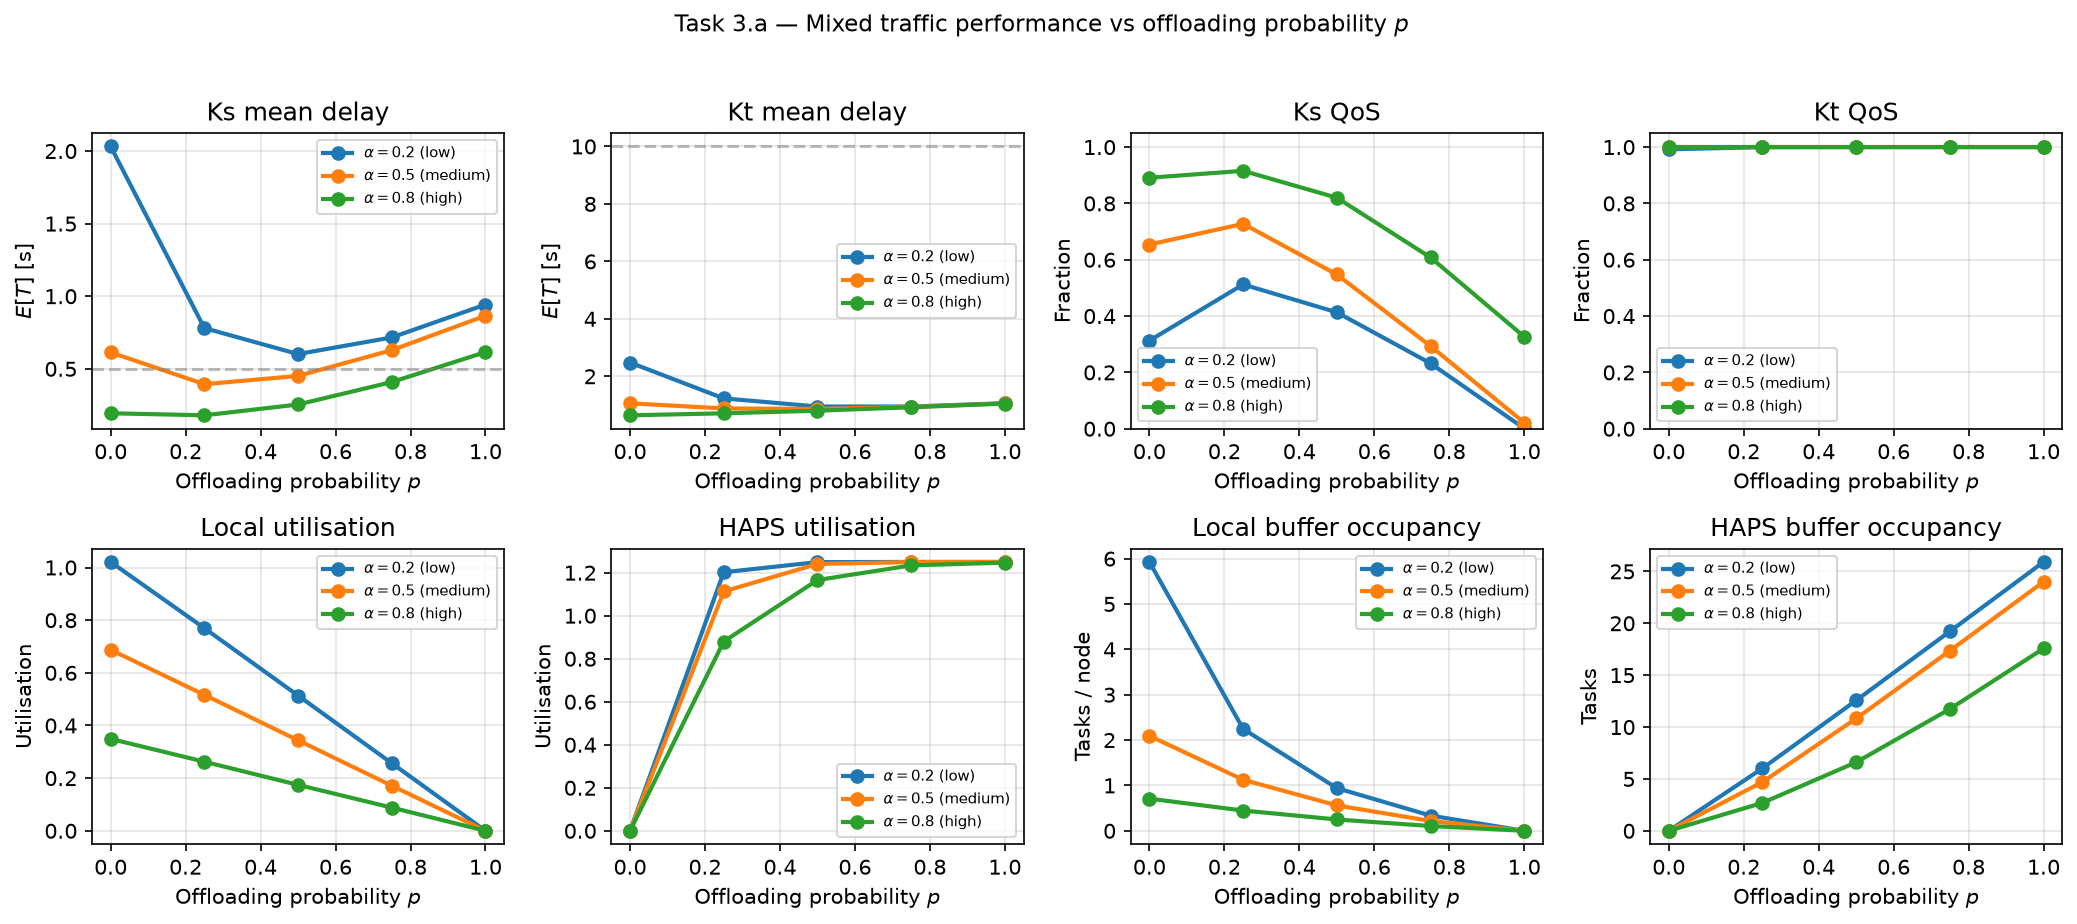

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
from IPython.display import Image, display

COLORS = {'low': '#1f77b4', 'medium': '#ff7f0e', 'high': '#2ca02c'}
LABELS = {
    'low':    r'$\alpha=0.2$ (low)',
    'medium': r'$\alpha=0.5$ (medium)',
    'high':   r'$\alpha=0.8$ (high)',
}

PANELS = [
    ('ET_Ks',    'Ks mean delay',              '$E[T]$ [s]'),
    ('ET_Kt',    'Kt mean delay',              '$E[T]$ [s]'),
    ('QoS_Ks',   'Ks QoS',                     'Fraction'),
    ('QoS_Kt',   'Kt QoS',                     'Fraction'),
    ('loc_util', 'Local utilisation',          'Utilisation'),
    ('hap_util', 'HAPS utilisation',           'Utilisation'),
    ('loc_occ',  'Local buffer occupancy',     'Tasks / node'),
    ('hap_occ',  'HAPS buffer occupancy',      'Tasks'),
]

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, (key, title, ylab) in zip(axes.flatten(), PANELS):
    for label in ALPHA_CFG:
        ax.plot(P_VALUES, results[label][key], 'o-', ms=6, lw=2,
                color=COLORS[label], label=LABELS[label])
    if key.startswith('ET_'):
        ax.axhline(TASKS[key.split('_')[1]]['Dmax'], ls='--', color='gray', alpha=0.5)
    if key.startswith('QoS_'):
        ax.set_ylim(0, 1.05)
    ax.set_xlabel('Offloading probability $p$')
    ax.set_ylabel(ylab)
    ax.set_title(title)
    ax.legend(fontsize=7, loc='best')
    ax.grid(True, alpha=0.35)

fig.suptitle('Task 3.a — Mixed traffic performance vs offloading probability $p$', fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('task3_mixed.png', dpi=150, bbox_inches='tight')
plt.close(fig)

display(Image('task3_mixed.png'))
print('Saved and displayed task3_mixed.png')

## Task 3.a — Observations and Report

### How coexistence changes the offloading trade-off

In Task 2, Ks and Kt were studied in isolation, so each class had its own optimal $p$. With both classes sharing the same local queues and HAPS pool, a single offloading probability must serve heterogeneous workloads simultaneously. The three $\alpha$ levels show how sensitive that compromise is to the traffic mix.

**Low $\alpha$ (0.2 — Kt-heavy).** At $p=0$, heavy Kt tasks saturate the local server and Ks delay rises far above its isolated level, even though Ks is only 20 % of traffic. Ks QoS falls to about 30 % because light tasks queue behind large neighbours. Moderate offloading ($p=0.25$–$0.5$) shifts the heavy work to the HAPS, sharply reducing Kt delay and improving Ks QoS, but pushing $p$ too high makes the HAPS the bottleneck — Ks tasks wait behind Kt uplink transfers and QoS drops again. Here, coexistence makes offloading **necessary** but **not extreme**: the trade-off is between local congestion from Kt and edge congestion from too much offloading.

**Medium $\alpha$ (0.5 — balanced).** Local load is lower than in the Kt-heavy case, so Ks starts in a better position at $p=0$. Still, Ks QoS peaks at low-to-moderate $p$ (around 0.25) rather than at zero, because half the traffic consists of heavy tasks that compete for the same local resource. Kt benefits from offloading throughout, but the best $p$ for Kt (higher) differs from the best $p$ for Ks (lower-to-moderate). Coexistence therefore **splits the optimum**: a compromise $p$ is needed rather than the class-specific extremes from Task 2.

**High $\alpha$ (0.8 — Ks-heavy).** Most traffic is light, so local utilisation stays moderate and Ks QoS is already near 90 % at $p=0$. Offloading is less critical for relieving local queues, but moderate $p$ still gives the best Ks QoS by moving the minority of heavy Kt tasks off the node. At high $p$, Ks delay and QoS degrade because unnecessary uplink traffic loads the HAPS. This mix most closely resembles the isolated Ks case, but the remaining 20 % Kt traffic is enough to show that **even a small heavy fraction couples the classes** through shared buffers.

### System load

Across all mixes, local utilisation and buffer occupancy decrease monotonically with $p$, while HAPS load grows. The shift is strongest when $\alpha$ is low, confirming that offloading primarily migrates Kt work. The load plots mirror the delay and QoS trends: the best operating point is where local congestion has been reduced without overloading the edge.

### Conclusion

Heterogeneous coexistence turns offloading into a **shared-resource problem**. Heavy Kt tasks raise the cost of local processing for everyone; aggressive offloading raises the cost of the HAPS path for everyone. The optimal $p$ depends on $\alpha$ — Kt-heavy mixes need more offloading to protect Ks, while Ks-heavy mixes can keep more work local. No single offloading policy fits all mixes, which is the key difference from the homogeneous Task 2 results.